In this file, I have been trying to imporve the model's ability to reach/learn the target (-z) at low sigma values. Unfortunately, no significant improvements so far.
For faster results, I took a small dataset and "small_data" and tried to train it only at a single low noise level. 
I have also incorporated embeddings for sigma since it enters the network only as a single scalar value. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from scipy.spatial.distance import pdist

In [2]:
training_configs = np.load("LJ13_configs.npy")

In [3]:
com = training_configs.mean(axis=1, keepdims=True)

training_configs_centered = training_configs - com


In [4]:
training_configs_centered_tensor = torch.tensor(training_configs_centered, dtype=torch.float32)

print(training_configs_centered_tensor.shape)

torch.Size([24994, 13, 3])


In [5]:
small_data = training_configs_centered_tensor[:10]

In [6]:
class MessageMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3*hidden_dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class FeatureMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class CoordMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3*hidden_dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        torch.nn.init.xavier_uniform_(
            self.net[-1].weight,
            gain=0.001
        )

        torch.nn.init.zeros_(
            self.net[-1].bias
        )

    def forward(self, x):
        return self.net(x)

In [9]:
class EGNNLayer(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.sigma_embedding = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.message_mlp = MessageMLP(hidden_dim)

        self.feature_mlp = FeatureMLP(hidden_dim)

        self.coord_mlp = CoordMLP(hidden_dim)

    def forward(self, x, h, log_sigma):

        N = x.shape[1]

        diff = x[:,:,None,:] - x[:,None,:,:]
        dist2 = (diff**2).sum(dim=-1, keepdim=True)

        hi = h[:,:,None,:]
        hi = hi.expand(-1,-1,N,-1)

        hj = h[:,None,:,:]
        hj = hj.expand(-1,N,-1,-1)

        sigma_emb = self.sigma_embedding(log_sigma)

        sigma_emb = sigma_emb[:,None,None,:]
        sigma_emb = sigma_emb.expand(-1,N,N,-1)

        message_input = torch.cat([hi, hj, dist2, sigma_emb], dim=-1)

        messages = self.message_mlp(message_input)

        agg_messages = messages.sum(dim=2)

        feature_input = torch.cat([h, agg_messages], dim=-1)

        feature_update = self.feature_mlp(feature_input)

        h_new = h + feature_update

        coord_weights = self.coord_mlp(message_input)

        coord_update = diff * coord_weights

        delta_x = coord_update.sum(dim=2)

        delta_x = delta_x / x.shape[1]

        x_new = x + delta_x

        return x_new, h_new, delta_x

    

In [10]:
class ScoreNetwork(nn.Module):

    def __init__(
        self,
        hidden_dim=64,
        num_layers=3
    ):
        super().__init__()

        self.embedding = nn.Linear(1, hidden_dim)

        self.layers = nn.ModuleList(
            [
                EGNNLayer(hidden_dim)
                for _ in range(num_layers)
            ]
        )


    def forward(self, x, log_sigma):

        atom_features = torch.ones(x.shape[0], x.shape[1], 1)

        h = self.embedding(atom_features)

        f_pred = torch.zeros_like(x)

        for layer in self.layers:

            x, h, delta_x = layer(x, h, log_sigma)

            f_pred = f_pred + delta_x

        f_pred = f_pred - f_pred.mean(dim=1, keepdim=True)


        return f_pred


In [11]:
X = training_configs_centered.reshape(training_configs_centered.shape[0],39)
X = torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

sigma_max = pdist(X_np).max()
sigma_min = 0.01

print("sigma_max:", sigma_max)

sigma_max: 6.440439591617135


In [12]:
def get_sigma(t):

    return sigma_min * (sigma_max/sigma_min)**t

In [13]:
def g(t):

    sigma = get_sigma(t)

    return (sigma * np.sqrt(2*np.log(sigma_max/sigma_min)))

In [66]:
from networkx import sigma


def train_model(
  optimizer_name="Adam",
  lr = 1e-4,
  width = 64,
  depth = 3,
  num_epochs = 5000  
):

    model = ScoreNetwork(hidden_dim=width,num_layers=depth)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    

    loss_history = []

  

    for epoch in range(num_epochs):

         x_batch = small_data

         sigma = torch.full((x_batch.shape[0], 1), 0.01)

         log_sigma = torch.log(sigma)

         sigma_expanded = sigma.view(-1,1,1)

         z = torch.randn_like(x_batch)

         z = z - z.mean(dim=1, keepdim=True)
            
         x_noisy = x_batch + sigma_expanded * z
            
         target = -z

         f_pred = model(x_noisy, log_sigma)

         loss_per_sample = ((f_pred - target) ** 2).sum(dim=(1,2))

        #weights = sigma.squeeze() ** 2

         loss = (loss_per_sample).mean()

         optimizer.zero_grad()

         loss.backward()
         torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
         )

         optimizer.step()
            
         loss_history.append(loss.item())

         if epoch % 100 == 0:
             print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")

    return model, loss_history

In [67]:
model, loss_history = train_model()

#torch.save(model.state_dict(), "lj13_f_theta_4.pth")

Epoch    0 | Loss = 40.055489
Epoch  100 | Loss = 35.501320
Epoch  200 | Loss = 35.774925
Epoch  300 | Loss = 39.214294
Epoch  400 | Loss = 32.809086
Epoch  500 | Loss = 33.689598
Epoch  600 | Loss = 33.200218
Epoch  700 | Loss = 37.054596
Epoch  800 | Loss = 32.342350
Epoch  900 | Loss = 41.270790
Epoch 1000 | Loss = 32.486767
Epoch 1100 | Loss = 42.130653
Epoch 1200 | Loss = 36.659149
Epoch 1300 | Loss = 35.541042
Epoch 1400 | Loss = 36.621075
Epoch 1500 | Loss = 33.141674
Epoch 1600 | Loss = 30.146351
Epoch 1700 | Loss = 35.492310
Epoch 1800 | Loss = 30.144348
Epoch 1900 | Loss = 32.467632
Epoch 2000 | Loss = 32.778790
Epoch 2100 | Loss = 31.957386
Epoch 2200 | Loss = 34.562531
Epoch 2300 | Loss = 31.778103
Epoch 2400 | Loss = 35.591999
Epoch 2500 | Loss = 30.237064
Epoch 2600 | Loss = 32.105358
Epoch 2700 | Loss = 40.509129
Epoch 2800 | Loss = 36.701351
Epoch 2900 | Loss = 31.648743
Epoch 3000 | Loss = 32.579964
Epoch 3100 | Loss = 31.274242
Epoch 3200 | Loss = 30.585709
Epoch 3300

Text(0, 0.5, 'Loss')

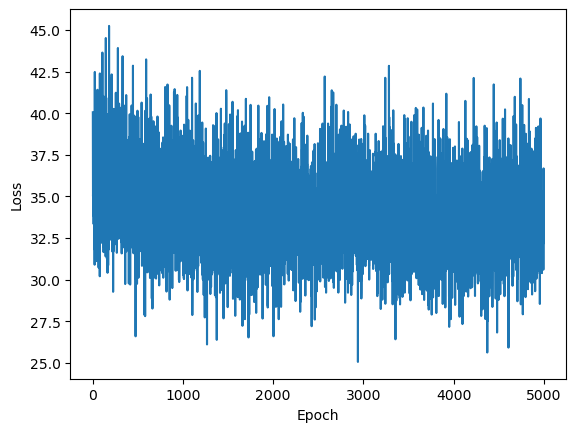

In [68]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [86]:
model.eval()

x = training_configs_centered_tensor[0:1]

for sigma_value in [0.01]:

    sigma = torch.tensor([[sigma_value]])

    noise = torch.randn_like(x)
    noise = noise - noise.mean(dim=1, keepdim=True)

    x_noisy = x + sigma.view(1, 1, 1) * noise
    log_sigma = torch.log(sigma)

    with torch.no_grad():
        f_pred = model(x_noisy, log_sigma)

    score_pred = f_pred / sigma.view(1, 1, 1)
    score_true = -noise / sigma.view(1, 1, 1)

    cosine = torch.nn.functional.cosine_similarity(
        score_pred.flatten(),
        score_true.flatten(),
        dim=0
    )

    magnitude_ratio = score_pred.norm() / score_true.norm()

    print(
        f"sigma = {sigma_value:5.2f} | "
        f"cosine = {cosine.item():.4f} | "
        f"magnitude ratio = {magnitude_ratio.item():.4f}"
    )

sigma =  0.01 | cosine = 0.4943 | magnitude ratio = 0.2086


In [19]:
def lj_energy(coords):

    N = coords.shape[0]

    energy = 0.0

    for i in range(N):
        for j in range(i + 1, N):

            r = torch.norm(coords[i] - coords[j])

            inv_r6 = (1.0 / r) ** 6
            inv_r12 = inv_r6 ** 2

            energy += 4 * (inv_r12 - inv_r6)

    return energy